# RQ2 Analysis: Transmodal Triangulation — Fragmentation of Shared Structure

This notebook visualises the results of the RQ2 fragmentation analysis.
It operates on the CSV produced by:

```bash
python -m src.run_rq2_triangulation \
    --run_id <RUN_ID> \
    --runs_root results/runs
```

**What is measured.**  For each directed triplet (A → B with witness C) and
each layer, we compute:

* `frag_global(A, B)` — fraction of B's variance linearly orthogonal to A.
* `frag_cka(A, B | C)` — CKA(residual, C) / CKA(B, C): fraction of the
  B–C shared structure remaining in the residual after projecting B onto A.
  Primary quantitative measure with BH-FDR significance.
* `sim_raw(R, C)` — raw PWCCA / kNN similarity between residual and C;
  reported alongside `sim(B, C)` for directional triangulation.

**Contents.**

1. Setup and data loading.
2. Sanity checks (self-projection, random control, null behaviour, asymmetry).
3. **Plot A** — Fragmentation triangulée CKA: grille 3×2 par paire × direction.
4. **Plot B** — Fragmentation globale par layer.
5. **Plot C** — Triangulation PWCCA et kNN: sim_residual vs sim_baseline.
6. **Plot D** — Asymétrie directionnelle: frag(A,B|C) − frag(B,A|C).
7. Report-ready summary table.

Set `RUN_ID` in the setup cell below.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ── Configuration ────────────────────────────────────────────────────────────
RUN_ID = "rq1_final_hypersim-20260525-000411"

project_root = Path("..") if Path("../README.md").exists() else Path(".")
results_path = project_root / "results" / "runs" / RUN_ID / "rq2" / "fragmentation_results.csv"

print(f"Run ID       : {RUN_ID}")
print(f"Results file : {results_path.resolve()}")
print(f"Exists       : {results_path.exists()}")

Run ID       : rq1_final_hypersim-20260525-000411
Results file : C:\Users\arthu\Desktop\EPFL\MA2\Visual Intelligence\one-trunk-or-many\results\runs\rq1_final_hypersim-20260525-000411\rq2\fragmentation_results.csv
Exists       : True


In [2]:
df = pd.read_csv(results_path)

# Derive canonical pair name (alphabetical) for grouping.
df["pair"] = df.apply(lambda r: "-".join(sorted([r["A"], r["B"]])), axis=1)

# Layer index for sorting and x-axis.
def _layer_idx(layer: str) -> int:
    return int(layer.split("_")[1])

df["layer_idx"] = df["layer"].map(_layer_idx)
df = df.sort_values(["pair", "A", "B", "C", "layer_idx"]).reset_index(drop=True)

LAYERS = sorted(df["layer"].unique(), key=_layer_idx)
LAYER_TICKS = [_layer_idx(l) for l in LAYERS]
PAIRS = sorted(df["pair"].unique())

print(f"Layers  : {LAYERS}")
print(f"Pairs   : {PAIRS}")
print(f"Rows    : {len(df)}")
print()
print("Observed frag_cka summary:")
display(
    df.groupby(["pair", "A", "B", "C"])["frag_cka"]
    .agg(["min", "mean", "max"])
    .round(3)
)

Layers  : ['layer_00', 'layer_01', 'layer_02', 'layer_03', 'layer_04', 'layer_05', 'layer_06', 'layer_07', 'layer_08', 'layer_09', 'layer_10', 'layer_11']
Pairs   : ['depth-normals', 'depth-rgb', 'normals-rgb']
Rows    : 72

Observed frag_cka summary:


min   mean    max
pair          A       B       C                           
depth-normals depth   normals rgb      0.097  0.154  0.283
              normals depth   rgb      0.194  0.235  0.292
depth-rgb     depth   rgb     normals  0.064  0.105  0.223
              rgb     depth   normals  0.102  0.245  0.519
normals-rgb   normals rgb     depth    0.106  0.137  0.184
              rgb     normals depth    0.066  0.183  0.452

## 2. Sanity Checks

Run these assertions before interpreting any results.
Expected outcomes are documented inline.


In [3]:
import sys
sys.path.insert(0, str(project_root))

from src.analysis.transmodal import frag_global as _frag_global
from src.pipeline.rq2_triangulation import stack_layer, load_trimodal_index

run_dir = project_root / "results" / "runs" / RUN_ID
trimodal_df = load_trimodal_index(run_dir)
X_rgb, X_depth, X_normals, scene_ids = stack_layer(trimodal_df, "layer_05")

# ── Check 1: self-projection ─────────────────────────────────────────────────
# frag_global(A, A) should be < 1e-3.  It is not exactly 0 because the ridge
# penalty introduces a small bias; this is expected behaviour.
self_frag = _frag_global(X_rgb, X_rgb)
print(f"[CHECK 1] frag_global(rgb, rgb) = {self_frag:.2e}  (expected < 1e-3)")
assert self_frag < 1e-3, f"Self-projection too large: {self_frag:.4f}"

# ── Check 2: random control ──────────────────────────────────────────────────
# frag_global(random_noise, B) should be > 0.75.
# Note: with D=512 and N=4000, OLS explains ~D/N≈12.8% of B from noise alone
# (hat-matrix overfitting), so the expected value is ~0.87, not ~1.0.
# A threshold of 0.75 catches pathological cases while accepting this artefact.
rng_check = np.random.default_rng(0)
noise = rng_check.standard_normal(X_depth.shape)
rand_frag = _frag_global(noise, X_depth)
print(f"[CHECK 2] frag_global(noise,  depth) = {rand_frag:.4f}  (expected > 0.75; typical ~0.87)")
assert rand_frag > 0.75, f"Random control too low: {rand_frag:.4f}"

# ── Check 3: null behaviour ──────────────────────────────────────────────────
# frag_cka null mean should be in [0.85, 1.05] on average — when A is
# mismatched, the residual retains nearly all of B, so frag ≈ 1.
valid_null_means = df["frag_cka_null_mean"].dropna()
null_avg = float(valid_null_means.mean())
print(f"[CHECK 3] mean(frag_cka_null_mean) = {null_avg:.4f}  (expected 0.85–1.05)")
assert 0.80 <= null_avg <= 1.10, f"Null mean out of expected range: {null_avg:.4f}"

# ── Check 4: asymmetry ───────────────────────────────────────────────────────
# frag(A, B|C) and frag(B, A|C) should differ because projection is asymmetric.
# Check the rgb-depth pair as example.
frag_ab = df[(df["A"]=="rgb") & (df["B"]=="depth")]["frag_cka"].dropna()
frag_ba = df[(df["A"]=="depth") & (df["B"]=="rgb")]["frag_cka"].dropna()
if len(frag_ab) > 0 and len(frag_ba) > 0:
    asym = float((frag_ab.values - frag_ba.values[:len(frag_ab)]).std())
    print(f"[CHECK 4] std(frag_ab − frag_ba) for rgb-depth = {asym:.4f}  (expected > 1e-6)")
    assert asym > 1e-6, "Fragmentation appears symmetric — check projection direction."

# ── Check 5: layer 0 notice ──────────────────────────────────────────────────
# layer_00 activations come near the tokenizer output; CKA(B, C) can be low,
# causing NaN frag_cka for some triplets.  This is expected and not a bug.
layer0_nan = df[df["layer"]=="layer_00"]["frag_cka"].isna().sum()
layer0_tot = len(df[df["layer"]=="layer_00"])
print(f"[CHECK 5] layer_00 NaN frag_cka: {layer0_nan}/{layer0_tot}  (NaN = denom below threshold, expected)") 

print("\n✓ All sanity checks passed.")

c:\Users\arthu\miniconda3\envs\nanofm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[CHECK 1] frag_global(rgb, rgb) = 1.69e-06  (expected < 1e-3)
[CHECK 2] frag_global(noise,  depth) = 0.8069  (expected > 0.75; typical ~0.87)
[CHECK 3] mean(frag_cka_null_mean) = 0.9842  (expected 0.85–1.05)
[CHECK 4] std(frag_ab − frag_ba) for rgb-depth = 0.0805  (expected > 1e-6)
[CHECK 5] layer_00 NaN frag_cka: 0/6  (NaN = denom below threshold, expected)

✓ All sanity checks passed.


## 3. Plot A — Fragmentation triangulée CKA

Grille 3×2 : trois paires non-ordonnées × deux directions.
Axe y = `frag_cka` ∈ [0, 1.1].  Bandes CI 95% bootstrap.  
Null mean en pointillés.  Marqueurs aux layers BH-FDR significatifs (p_adj < 0.05).


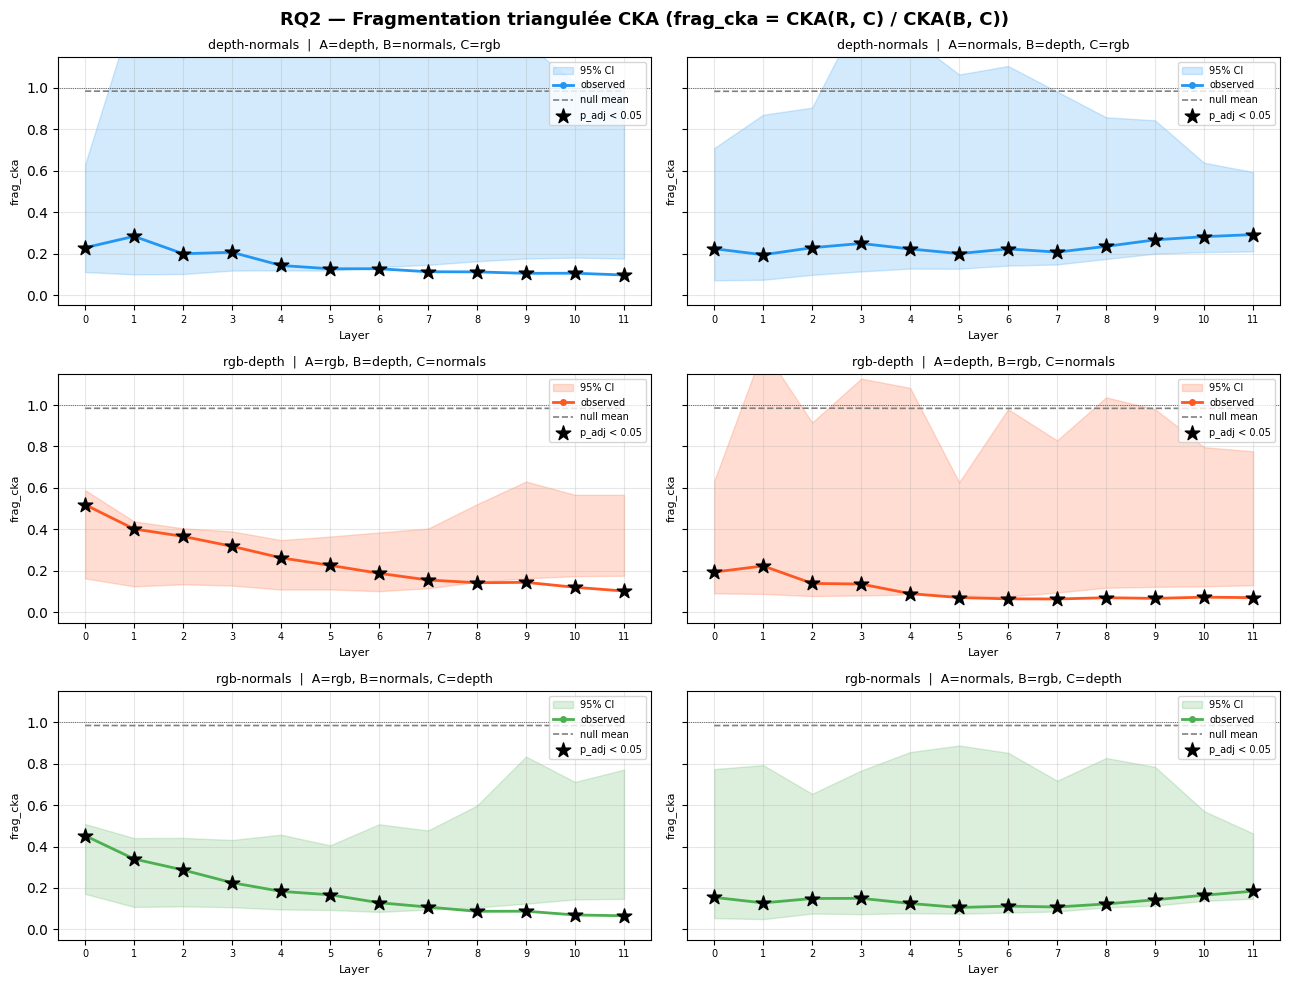

In [4]:
PAIR_COLORS = {
    "depth-normals": "#2196F3",
    "rgb-depth":     "#FF5722",
    "rgb-normals":   "#4CAF50",
}

# Build (pair, direction) list in a stable order.
directions = [
    ("depth-normals", "depth",   "normals", "normals", "rgb"),
    ("depth-normals", "normals", "depth",   "depth",   "rgb"),
    ("rgb-depth",     "rgb",     "depth",   "depth",   "normals"),
    ("rgb-depth",     "depth",   "rgb",     "rgb",     "normals"),
    ("rgb-normals",   "rgb",     "normals", "normals", "depth"),
    ("rgb-normals",   "normals", "rgb",     "rgb",     "depth"),
]

fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharey=True)
fig.suptitle("RQ2 — Fragmentation triangulée CKA (frag_cka = CKA(R, C) / CKA(B, C))",
             fontsize=13, fontweight="bold")

for ax, (pair, A, B, C_label, _C) in zip(axes.flat, directions):
    sub = df[(df["A"] == A) & (df["B"] == B)].sort_values("layer_idx")
    x   = sub["layer_idx"].values
    y   = sub["frag_cka"].values
    ci_lo = sub["frag_cka_ci_lo"].values
    ci_hi = sub["frag_cka_ci_hi"].values
    null_m = sub["frag_cka_null_mean"].values
    sig    = sub["frag_cka_p_adj"].fillna(1.0) < 0.05

    color = PAIR_COLORS.get(pair, "#9C27B0")

    ax.fill_between(x, ci_lo, ci_hi, alpha=0.2, color=color, label="95% CI")
    ax.plot(x, y, color=color, linewidth=2, marker="o", markersize=4, label="observed")
    ax.plot(x, null_m, color="grey", linewidth=1.2, linestyle="--", label="null mean")

    # Mark significant layers.
    if sig.any():
        ax.scatter(x[sig], y[sig], marker="*", s=120, color="black",
                   zorder=5, label="p_adj < 0.05")

    ax.set_title(f"{pair}  |  A={A}, B={B}, C={_C}", fontsize=9)
    ax.set_xlabel("Layer", fontsize=8)
    ax.set_ylabel("frag_cka", fontsize=8)
    ax.set_ylim(-0.05, 1.15)
    ax.set_xticks(LAYER_TICKS)
    ax.set_xticklabels([str(t) for t in LAYER_TICKS], fontsize=7)
    ax.axhline(1.0, color="black", linewidth=0.5, linestyle=":")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / "results" / "runs" / RUN_ID / "rq2" / "plot_A_frag_cka.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 4. Plot B — Fragmentation globale

Les six directions superposées.  Axe y = `frag_global` ∈ [0, 1].  
Bandes CI 95% bootstrap.  Interprétation : fraction de la variance de B
linéairement inexpliquée par A.


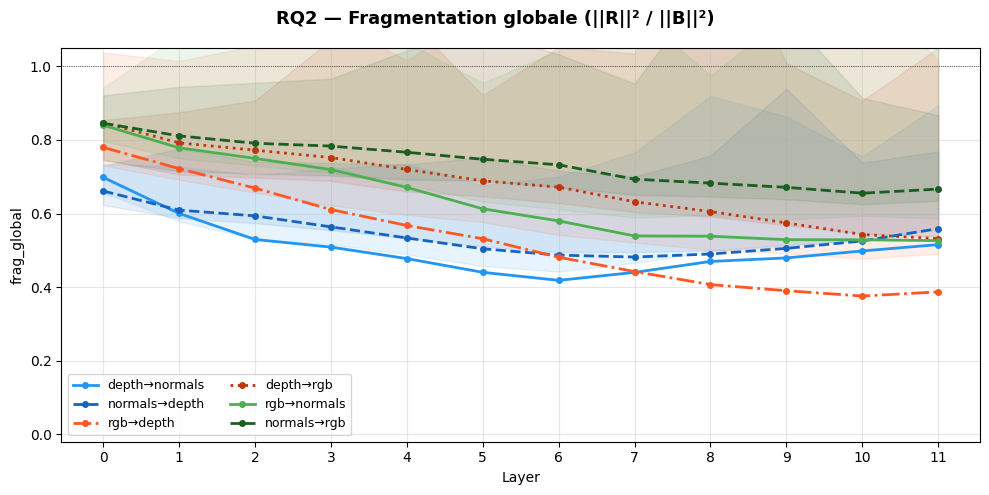

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("RQ2 — Fragmentation globale (||R||² / ||B||²)", fontsize=13, fontweight="bold")

linestyles = ["-", "--", "-.", ":", "-", "--"]
colors_dir = ["#2196F3", "#1565C0", "#FF5722", "#BF360C", "#4CAF50", "#1B5E20"]

for i, (pair, A, B, _C_label, _C) in enumerate(directions):
    sub = df[(df["A"] == A) & (df["B"] == B)].sort_values("layer_idx")
    x     = sub["layer_idx"].values
    y     = sub["frag_global"].values
    ci_lo = sub["frag_global_ci_lo"].values
    ci_hi = sub["frag_global_ci_hi"].values
    label = f"{A}→{B}"

    ax.fill_between(x, ci_lo, ci_hi, alpha=0.1, color=colors_dir[i])
    ax.plot(x, y, color=colors_dir[i], linewidth=2,
            linestyle=linestyles[i], marker="o", markersize=4, label=label)

ax.set_xlabel("Layer", fontsize=10)
ax.set_ylabel("frag_global", fontsize=10)
ax.set_ylim(-0.02, 1.05)
ax.set_xticks(LAYER_TICKS)
ax.set_xticklabels([str(t) for t in LAYER_TICKS])
ax.axhline(1.0, color="black", linewidth=0.5, linestyle=":")
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(project_root / "results" / "runs" / RUN_ID / "rq2" / "plot_B_frag_global.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 5. Plot C — Triangulation PWCCA et kNN

Pour chaque direction, deux courbes : `sim_r` (résidu × witness) vs `sim_b`
(B × witness).  Une décroissance de `sim_r` relativement à `sim_b` confirme
que le résidu perd de la structure géométrique à travers les couches.  Les
valeurs absolues ne sont **pas** interprétables comme des fractions (ratio
non-défini pour PWCCA / kNN).


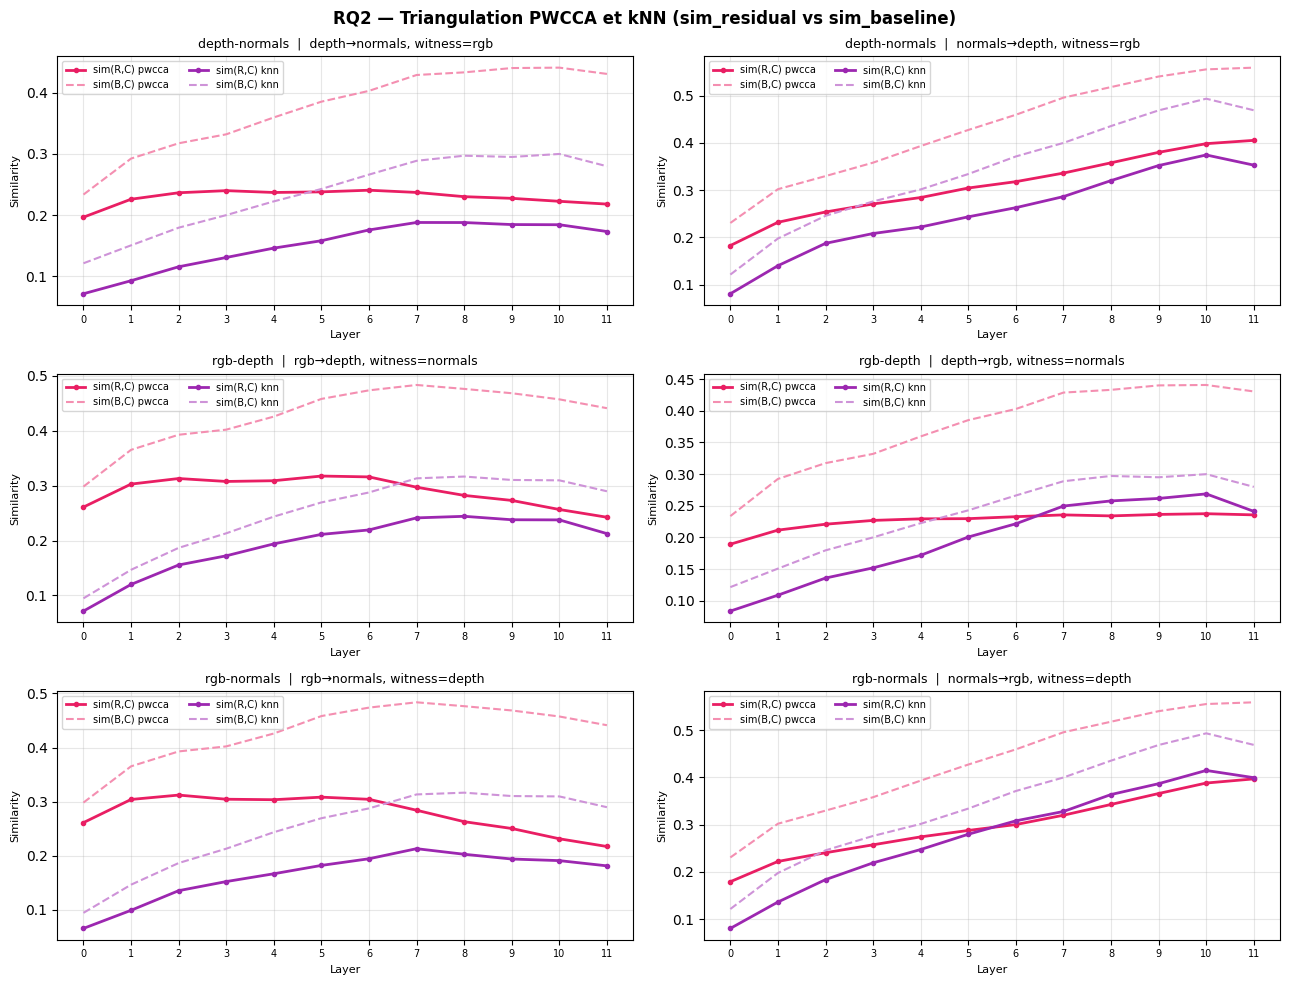

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10))
fig.suptitle("RQ2 — Triangulation PWCCA et kNN (sim_residual vs sim_baseline)",
             fontsize=12, fontweight="bold")

for ax, (pair, A, B, C_label, _C) in zip(axes.flat, directions):
    sub = df[(df["A"] == A) & (df["B"] == B)].sort_values("layer_idx")
    x = sub["layer_idx"].values

    for metric, color_r, color_b in [
        ("pwcca", "#E91E63", "#F48FB1"),
        ("knn",   "#9C27B0", "#CE93D8"),
    ]:
        r_vals  = sub[f"sim_r_{metric}"].values
        b_vals  = sub[f"sim_b_{metric}"].values
        r_ci_lo = sub[f"sim_r_{metric}_ci_lo"].values
        r_ci_hi = sub[f"sim_r_{metric}_ci_hi"].values

        ax.fill_between(x, r_ci_lo, r_ci_hi, alpha=0.12, color=color_r)
        ax.plot(x, r_vals, color=color_r, linewidth=2, marker="o", markersize=3,
                label=f"sim(R,C) {metric}")
        ax.plot(x, b_vals, color=color_b, linewidth=1.5, linestyle="--",
                label=f"sim(B,C) {metric}")

    ax.set_title(f"{pair}  |  {A}→{B}, witness={_C}", fontsize=9)
    ax.set_xlabel("Layer", fontsize=8)
    ax.set_ylabel("Similarity", fontsize=8)
    ax.set_xticks(LAYER_TICKS)
    ax.set_xticklabels([str(t) for t in LAYER_TICKS], fontsize=7)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / "results" / "runs" / RUN_ID / "rq2" / "plot_C_triangulation_pwcca_knn.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 6. Plot D — Asymétrie directionnelle

`frag(A, B|C) − frag(B, A|C)` par layer pour chaque paire.  
Valeur positive : A absorbe mieux la structure partagée que B.  
Valeur négative : B absorbe mieux.


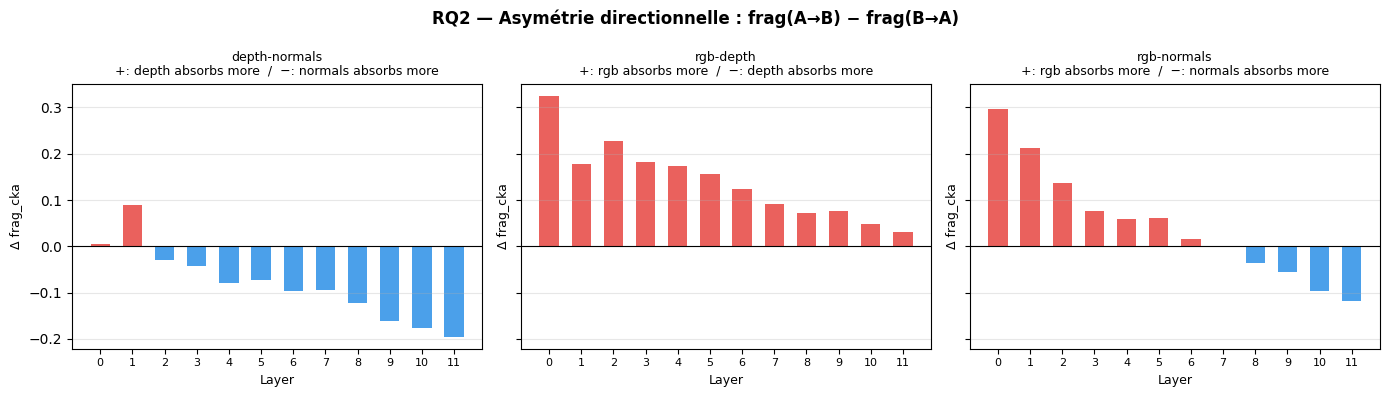

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("RQ2 — Asymétrie directionnelle : frag(A→B) − frag(B→A)",
             fontsize=12, fontweight="bold")

PAIR_ASYM = [
    ("depth-normals", "depth",   "normals", "normals", "rgb"),
    ("rgb-depth",     "rgb",     "depth",   "depth",   "normals"),
    ("rgb-normals",   "rgb",     "normals", "normals", "depth"),
]

for ax, (pair, A, B, _B_rev, _C) in zip(axes, PAIR_ASYM):
    sub_ab = df[(df["A"] == A) & (df["B"] == B)].sort_values("layer_idx")
    sub_ba = df[(df["A"] == B) & (df["B"] == A)].sort_values("layer_idx")

    x   = sub_ab["layer_idx"].values
    asym = sub_ab["frag_cka"].values - sub_ba["frag_cka"].values

    bar_colors = ["#E53935" if v > 0 else "#1E88E5" for v in asym]
    ax.bar(x, asym, color=bar_colors, alpha=0.8, width=0.6)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{pair}\n+: {A} absorbs more  /  −: {B} absorbs more", fontsize=9)
    ax.set_xlabel("Layer", fontsize=9)
    ax.set_ylabel("Δ frag_cka", fontsize=9)
    ax.set_xticks(LAYER_TICKS)
    ax.set_xticklabels([str(t) for t in LAYER_TICKS], fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / "results" / "runs" / RUN_ID / "rq2" / "plot_D_asymmetry.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 7. Report-ready Summary Table

Mean `frag_cka` per pair (symmetrised average of both directions), with
bootstrap CI and BH-FDR p-values at the final layer.


In [9]:
# ── Symmetrised frag_cka per (pair, layer) ───────────────────────────────────
sym = (
    df.groupby(["pair", "layer", "layer_idx"])
    .agg(
        frag_cka_mean=("frag_cka", "mean"),
        frag_cka_ci_lo=("frag_cka_ci_lo", "mean"),
        frag_cka_ci_hi=("frag_cka_ci_hi", "mean"),
        frag_cka_p_adj_min=("frag_cka_p_adj", "min"),  # most significant direction
    )
    .reset_index()
    .sort_values(["pair", "layer_idx"])
)

# ── Delta (layer 0 → last layer) per pair ────────────────────────────────────
layer_first = LAYERS[0]
layer_last  = LAYERS[-1]

delta_rows = []
for pair in PAIRS:
    f0 = sym[(sym["pair"] == pair) & (sym["layer"] == layer_first)]["frag_cka_mean"].values
    fL = sym[(sym["pair"] == pair) & (sym["layer"] == layer_last)]["frag_cka_mean"].values
    if len(f0) > 0 and len(fL) > 0:
        delta_rows.append({
            "pair": pair,
            "frag_layer0":  float(f0[0]),
            "frag_layerL":  float(fL[0]),
            "delta_frag":   float(f0[0] - fL[0]),  # positive = less fragmentation at end
        })

delta_df = pd.DataFrame(delta_rows).set_index("pair")
print("=" * 60)
print("Fragmentation reduction (Δ = layer0 − lastlayer):")
print("Positive Δ = encoder reduced fragmentation across layers.")
display(delta_df.round(4))

print()
print(f"Symmetrised frag_cka at final layer ({layer_last}):")
display(
    sym[sym["layer"] == layer_last][["pair", "frag_cka_mean", "frag_cka_ci_lo",
                                     "frag_cka_ci_hi", "frag_cka_p_adj_min"]]
    .set_index("pair")
    .round(4)
)

# ── Save table ────────────────────────────────────────────────────────────────
out_table = project_root / "notebooks" / f"rq2_{RUN_ID}_fragmentation_summary.csv"
sym.to_csv(out_table, index=False)
print(f"\nSaved summary table to: {out_table}")

Fragmentation reduction (Δ = layer0 − lastlayer):
Positive Δ = encoder reduced fragmentation across layers.


,frag_layer0,frag_layerL,delta_frag
pair,,,
depth-normals,0.2261,0.1943,0.0319
depth-rgb,0.3562,0.0863,0.2700
normals-rgb,0.3034,0.1251,0.1783



Symmetrised frag_cka at final layer (layer_11):


,frag_cka_mean,frag_cka_ci_lo,frag_cka_ci_hi,frag_cka_p_adj_min
pair,,,,
depth-normals,0.1943,0.1933,0.7991,0.001
depth-rgb,0.0863,0.1529,0.6718,0.001
normals-rgb,0.1251,0.1478,0.6172,0.001



Saved summary table to: ..\notebooks\rq2_rq1_final_hypersim-20260525-000411_fragmentation_summary.csv


## 8. Significance Overview

Count of BH-FDR significant cells (p_adj < 0.05) per pair and direction.


BH-FDR significance summary (α = 0.05):


,pair,A,B,n_layers,n_sig,pct_sig
0,depth-normals,depth,normals,12,12,100.0
1,depth-normals,normals,depth,12,12,100.0
2,depth-rgb,depth,rgb,12,12,100.0
3,depth-rgb,rgb,depth,12,12,100.0
4,normals-rgb,normals,rgb,12,12,100.0
5,normals-rgb,rgb,normals,12,12,100.0


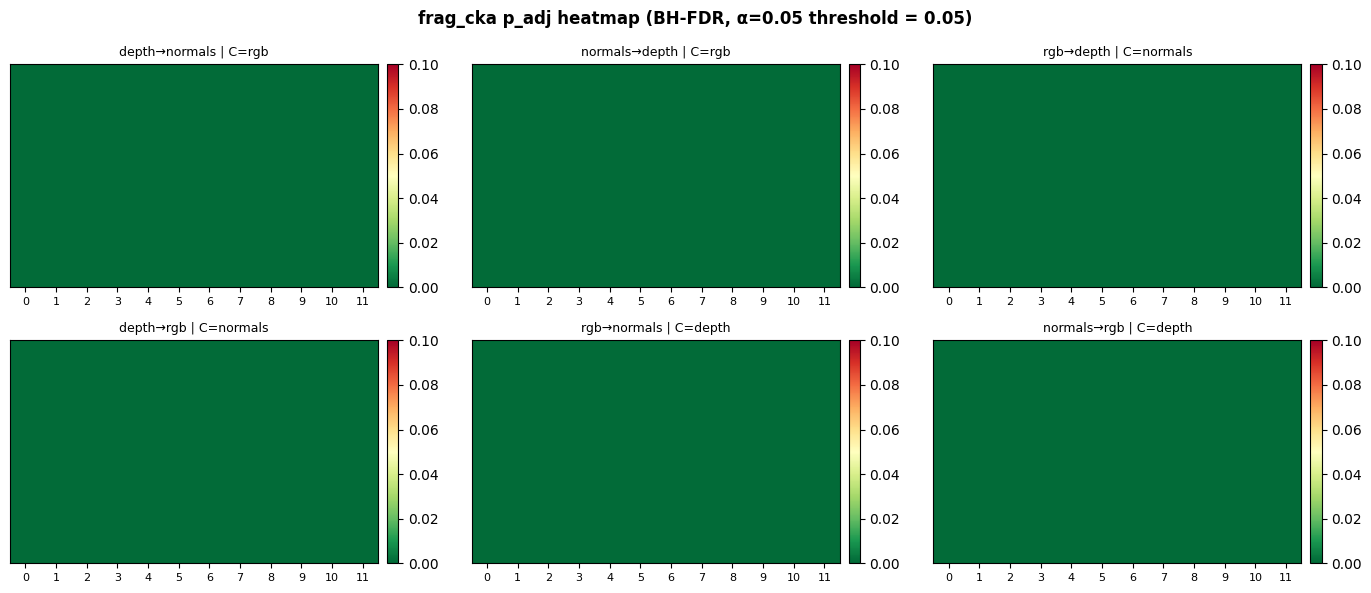

In [10]:
sig_df = df[df["frag_cka_p_adj"].notna()].copy()
sig_df["significant"] = sig_df["frag_cka_p_adj"] < 0.05

sig_summary = (
    sig_df.groupby(["pair", "A", "B"])
    .agg(
        n_layers=("layer", "count"),
        n_sig=("significant", "sum"),
    )
    .assign(pct_sig=lambda x: (x["n_sig"] / x["n_layers"] * 100).round(1))
    .reset_index()
)

print("BH-FDR significance summary (α = 0.05):")
display(sig_summary)

# ── Heatmap of p_adj ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle("frag_cka p_adj heatmap (BH-FDR, α=0.05 threshold = 0.05)",
             fontsize=12, fontweight="bold")

for ax, (pair, A, B, _C_l, _C) in zip(axes.flat, directions):
    sub = df[(df["A"] == A) & (df["B"] == B)].sort_values("layer_idx")
    vals = sub["frag_cka_p_adj"].fillna(1.0).values.reshape(1, -1)
    im = ax.imshow(vals, aspect="auto", cmap="RdYlGn_r",
                   vmin=0.0, vmax=0.1, interpolation="nearest")
    ax.set_xticks(range(len(LAYER_TICKS)))
    ax.set_xticklabels([str(t) for t in LAYER_TICKS], fontsize=8)
    ax.set_yticks([])
    ax.set_title(f"{A}→{B} | C={_C}", fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.15, pad=0.02)

plt.tight_layout()
plt.savefig(project_root / "results" / "runs" / RUN_ID / "rq2" / "plot_E_pvalue_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Plot E — Présentation : unification progressive par paire (symétrisée)

Graphe synthétique pour présentation orale. Chaque courbe est la moyenne des deux
directions d'une paire (ex. `rgb→depth` et `depth→rgb` moyennées). Montre en un
coup d'oeil les deux claims principaux : (1) l'unification progresse avec la
profondeur, (2) elle est asymétrique entre paires — RGB est le hub.

Saved: ..\notebooks\rq2_presentation_rq1_final_hypersim-20260525-000411.png


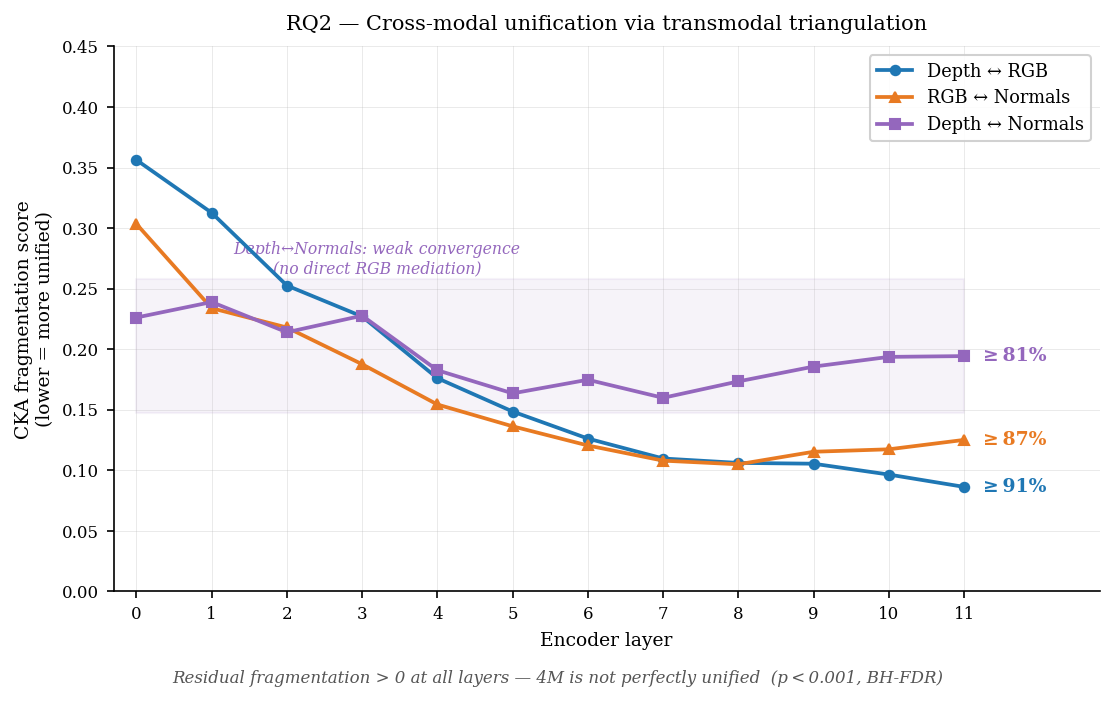

In [14]:
# ── Plot E — Presentation: symmetrised frag_cka per pair (annotated) ─────────
# Style mirrors rq1_multipair_hypersim_diode.ipynb (serif, grid, RQ1 pair colours).

import matplotlib as mpl
_prev_rc = dict(mpl.rcParams)   # save to restore after this cell

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "pdf.fonttype":      42,
    "font.family":       "serif",
    "font.size":         9,
    "axes.labelsize":    9,
    "axes.titlesize":    10,
    "legend.fontsize":   8.5,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linewidth":    0.4,
    "lines.linewidth":   1.4,
})

sym_e = (
    df.groupby(["pair", "layer_idx"])
    .agg(frag_cka_mean=("frag_cka", "mean"))
    .reset_index()
    .sort_values(["pair", "layer_idx"])
)

# Match RQ1 pair colours and markers exactly
PAIR_COLORS_E = {"depth-rgb": "#1f77b4", "normals-rgb": "#e87a22", "depth-normals": "#9467bd"}
PAIR_MARKER_E = {"depth-rgb": "o",       "normals-rgb": "^",       "depth-normals": "s"}
PAIR_LABELS_E = {"depth-rgb": "Depth \u2194 RGB", "normals-rgb": "RGB \u2194 Normals", "depth-normals": "Depth \u2194 Normals"}

unif_lb = {}
for pair in PAIRS:
    v = sym_e[(sym_e["pair"] == pair) & (sym_e["layer_idx"] == 11)]["frag_cka_mean"].values[0]
    unif_lb[pair] = 1.0 - v

fig, ax = plt.subplots(figsize=(6.0, 5.2))

# ── Shaded zone for depth-normals (hub visual cue) ────────────────────────────
dn_vals = sym_e[sym_e["pair"] == "depth-normals"].sort_values("layer_idx")["frag_cka_mean"].values
ax.fill_between(range(12), dn_vals.min() * 0.92, dn_vals.max() * 1.08,
                color="#9467bd", alpha=0.08, zorder=1)
ax.text(7.5, dn_vals.max() * 1.10,
        "Depth\u2194Normals: weak convergence\n(no direct RGB mediation)",
        fontsize=7.5, color="#9467bd", ha="center", style="italic")

# ── Curves ────────────────────────────────────────────────────────────────────
for pair in ["depth-rgb", "normals-rgb", "depth-normals"]:
    sub   = sym_e[sym_e["pair"] == pair].sort_values("layer_idx")
    x     = sub["layer_idx"].values
    y     = sub["frag_cka_mean"].values
    color = PAIR_COLORS_E[pair]
    pct   = f"\u2265\u2009{unif_lb[pair]:.0%}"   # ≥ XX%

    ax.plot(x, y, color=color, linewidth=1.8,
            marker=PAIR_MARKER_E[pair], markersize=4.5,
            label=PAIR_LABELS_E[pair], zorder=3)
    ax.annotate(pct, xy=(x[-1], y[-1]), xytext=(x[-1] + 0.25, y[-1]),
                fontsize=9, color=color, fontweight="bold", va="center")

# ── Bottom caption ────────────────────────────────────────────────────────────
fig.text(
    0.5, -0.02,
    "Residual fragmentation > 0 at all layers \u2014 4M is not perfectly unified  (p\u202f<\u202f0.001, BH-FDR)",
    ha="center", fontsize=8, color="#555555", style="italic",
)

ax.set_xlabel("Encoder layer")
ax.set_ylabel("CKA fragmentation score\n(lower = more unified)")
ax.set_title(
    "RQ2 \u2014 Cross-modal unification via transmodal triangulation",
    pad=8,
)
ax.set_xticks(LAYER_TICKS)
ax.set_xticklabels([str(t) for t in LAYER_TICKS])
ax.set_ylim(0.0, 0.45)
ax.set_xlim(-0.3, 12.8)
ax.legend(loc="upper right", framealpha=0.9)

plt.tight_layout()
out_png = project_root / "notebooks" / f"rq2_presentation_{RUN_ID}.png"
fig.savefig(out_png, bbox_inches="tight")
print(f"Saved: {out_png}")
plt.show()

# Restore previous rcParams so other cells are unaffected
mpl.rcParams.update(_prev_rc)